# Task 2: Sentiment Analysis Using Rule-Based Tools

**Dataset:** `tech_tweets.csv` — tweets related to technology with ground-truth sentiment labels.

**Approach:** VADER (Valence Aware Dictionary and sEntiment Reasoner) — a lexicon and rule-based sentiment analysis tool specifically attuned to social media text.

---
## 0. Imports and Setup

In [1]:
import re
import string
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# Download required NLTK resources
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
print('Setup complete.')

Setup complete.


---
## 1. Data Preprocessing

**Objective:** Clean and prepare tweet text for sentiment analysis.

In [2]:
# Load the dataset
df = pd.read_csv('datasets/tech_tweets.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nSentiment distribution:')
print(df['sentiment'].value_counts())
df.head(10)

Dataset shape: (5000, 4)

Columns: ['tweet_id', 'company', 'tweet_text', 'sentiment']

Sentiment distribution:
sentiment
positive    1684
neutral     1666
negative    1650
Name: count, dtype: int64


,tweet_id,company,tweet_text,sentiment
0,1,Apple,Apple's performance is top-notch. Kudos to the...,positive
1,2,Google,Great customer service from Google. Totally sa...,positive
2,3,Apple,Still exploring Apple. Too early to judge.,neutral
3,4,Apple,Tried out Apple. Mixed feelings about it.,neutral
4,5,Apple,The new Apple update is amazing! Loving the fe...,positive
5,6,Google,Fast and reliable – Google never disappoints!,positive
6,7,Meta,Fast and reliable – Meta never disappoints!,positive
7,8,Google,Still exploring Google. Too early to judge.,neutral
8,9,Microsoft,Impressed with Microsoft's latest product rele...,positive
9,10,Meta,Really disappointed with Meta. Not what I expe...,negative


In [3]:
def clean_tweet(text):
    """Clean a tweet by removing noise elements."""
    # Lowercase
    text = text.lower()
    # Remove URLs (http/https/www)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove #hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Collapse extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_tweet'] = df['tweet_text'].apply(clean_tweet)

# Show before / after
comparison = df[['tweet_text', 'cleaned_tweet']].head(8)
pd.set_option('display.max_colwidth', 120)
print('Sample: original vs cleaned')
comparison

Sample: original vs cleaned


,tweet_text,cleaned_tweet
0,Apple's performance is top-notch. Kudos to the team!,apples performance is topnotch kudos to the team
1,Great customer service from Google. Totally satisfied!,great customer service from google totally satisfied
2,Still exploring Apple. Too early to judge.,still exploring apple too early to judge
3,Tried out Apple. Mixed feelings about it.,tried out apple mixed feelings about it
4,The new Apple update is amazing! Loving the features.,the new apple update is amazing loving the features
5,Fast and reliable – Google never disappoints!,fast and reliable – google never disappoints
6,Fast and reliable – Meta never disappoints!,fast and reliable – meta never disappoints
7,Still exploring Google. Too early to judge.,still exploring google too early to judge


In [4]:
# Optional: tokenise using NLTK
stop_words = set(stopwords.words('english'))

def tokenise(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

df['tokens'] = df['cleaned_tweet'].apply(tokenise)

print('Sample tokenised tweets (stop-words removed):')
df[['cleaned_tweet', 'tokens']].head(5)

Sample tokenised tweets (stop-words removed):


,cleaned_tweet,tokens
0,apples performance is topnotch kudos to the team,"[apples, performance, topnotch, kudos, team]"
1,great customer service from google totally satisfied,"[great, customer, service, google, totally, satisfied]"
2,still exploring apple too early to judge,"[still, exploring, apple, early, judge]"
3,tried out apple mixed feelings about it,"[tried, apple, mixed, feelings]"
4,the new apple update is amazing loving the features,"[new, apple, update, amazing, loving, features]"


---
## 2. Sentiment Analysis with VADER

**Objective:** Classify tweet sentiment using the VADER rule-based tool.

VADER returns a **compound score** in the range \[-1, 1\]:
- `compound > 0` → **Positive**
- `compound < 0` → **Negative**
- `compound == 0` → **Neutral**

In [5]:
sia = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = sia.polarity_scores(text)
    return scores['compound']

def label_sentiment(compound):
    if compound > 0:
        return 'positive'
    elif compound < 0:
        return 'negative'
    else:
        return 'neutral'

# Apply to cleaned tweets
df['compound_score'] = df['cleaned_tweet'].apply(get_vader_scores)
df['predicted_sentiment'] = df['compound_score'].apply(label_sentiment)

print('Predicted sentiment distribution:')
print(df['predicted_sentiment'].value_counts())

df[['tweet_text', 'cleaned_tweet', 'compound_score', 'predicted_sentiment', 'sentiment']].head(10)

Predicted sentiment distribution:
predicted_sentiment
positive    2639
negative    1799
neutral      562
Name: count, dtype: int64


,tweet_text,cleaned_tweet,compound_score,predicted_sentiment,sentiment
0,Apple's performance is top-notch. Kudos to the team!,apples performance is topnotch kudos to the team,0.5106,positive,positive
1,Great customer service from Google. Totally satisfied!,great customer service from google totally satisfied,0.8016,positive,positive
2,Still exploring Apple. Too early to judge.,still exploring apple too early to judge,0.0000,neutral,neutral
3,Tried out Apple. Mixed feelings about it.,tried out apple mixed feelings about it,0.0000,neutral,neutral
4,The new Apple update is amazing! Loving the features.,the new apple update is amazing loving the features,0.8271,positive,positive
5,Fast and reliable – Google never disappoints!,fast and reliable – google never disappoints,0.2924,positive,positive
6,Fast and reliable – Meta never disappoints!,fast and reliable – meta never disappoints,0.2924,positive,positive
7,Still exploring Google. Too early to judge.,still exploring google too early to judge,0.0000,neutral,neutral
8,Impressed with Microsoft's latest product release.,impressed with microsofts latest product release,0.4767,positive,positive
9,Really disappointed with Meta. Not what I expected.,really disappointed with meta not what i expected,-0.5256,negative,negative


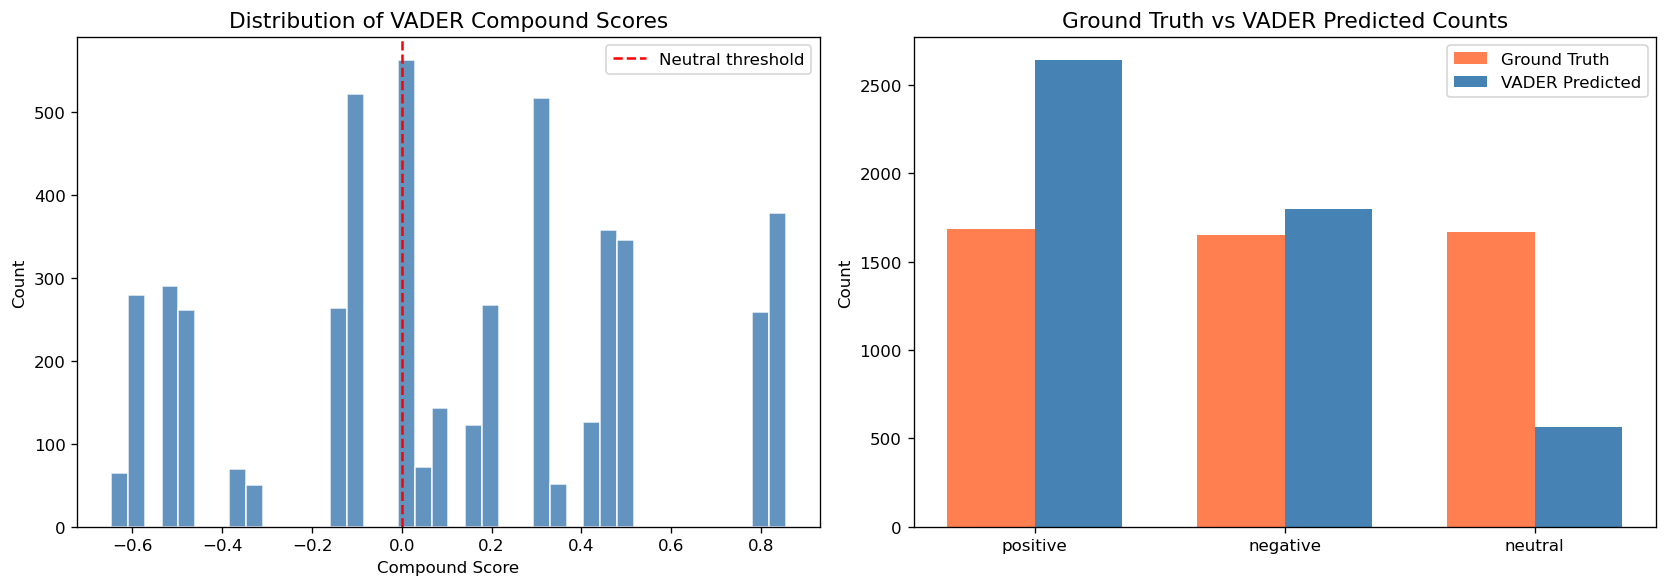

In [6]:
# Visualise distribution of compound scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of compound scores
axes[0].hist(df['compound_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', label='Neutral threshold')
axes[0].set_title('Distribution of VADER Compound Scores', fontsize=13)
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Predicted vs actual label counts
pred_counts = df['predicted_sentiment'].value_counts()
actual_counts = df['sentiment'].value_counts()
labels = ['positive', 'negative', 'neutral']
x = np.arange(len(labels))
width = 0.35
axes[1].bar(x - width/2, [actual_counts.get(l, 0) for l in labels], width, label='Ground Truth', color='coral')
axes[1].bar(x + width/2, [pred_counts.get(l, 0) for l in labels], width, label='VADER Predicted', color='steelblue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Ground Truth vs VADER Predicted Counts', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('task2_score_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. Compare with Ground Truth Labels

**Objective:** Evaluate the VADER predictions against actual sentiment labels.

In [7]:
y_true = df['sentiment']
y_pred = df['predicted_sentiment']

accuracy = accuracy_score(y_true, y_pred)
print(f'Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

print('\nDetailed Classification Report:')
print(classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive']))

Overall Accuracy: 0.6908 (69.08%)

Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.73      0.70      1650
     neutral       1.00      0.34      0.50      1666
    positive       0.64      1.00      0.78      1684

    accuracy                           0.69      5000
   macro avg       0.77      0.69      0.66      5000
weighted avg       0.77      0.69      0.66      5000



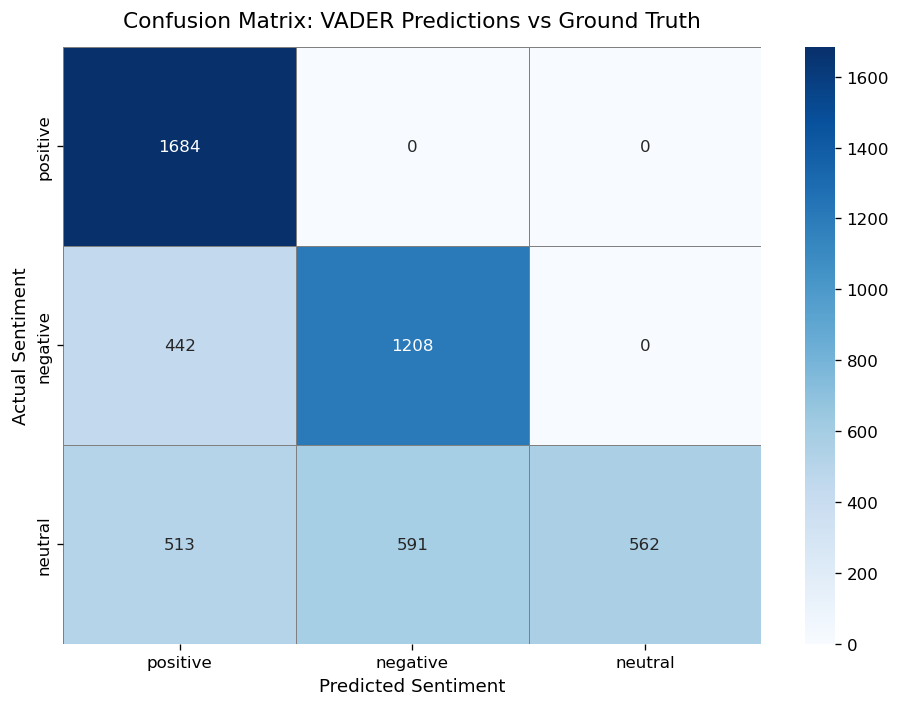


Confusion Matrix (rows=actual, cols=predicted):
          positive  negative  neutral
positive      1684         0        0
negative       442      1208        0
neutral        513       591      562


In [8]:
# Confusion Matrix — Seaborn heatmap
labels_order = ['positive', 'negative', 'neutral']
cm = confusion_matrix(y_true, y_pred, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order,
    linewidths=0.5,
    linecolor='grey'
)
plt.title('Confusion Matrix: VADER Predictions vs Ground Truth', fontsize=13, pad=12)
plt.xlabel('Predicted Sentiment', fontsize=11)
plt.ylabel('Actual Sentiment', fontsize=11)
plt.tight_layout()
plt.savefig('task2_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'\nConfusion Matrix (rows=actual, cols=predicted):')
print(pd.DataFrame(cm, index=labels_order, columns=labels_order))

In [9]:
# Per-class accuracy breakdown
for label in labels_order:
    subset = df[df['sentiment'] == label]
    correct = (subset['predicted_sentiment'] == label).sum()
    pct = correct / len(subset) * 100
    print(f'{label.capitalize():10s} — {correct}/{len(subset)} correct ({pct:.1f}%)')

Positive   — 1684/1684 correct (100.0%)
Negative   — 1208/1650 correct (73.2%)
Neutral    — 562/1666 correct (33.7%)


---
## 4. Interpretation and Reflection

In [10]:
# Inspect misclassified tweets
errors = df[df['sentiment'] != df['predicted_sentiment']].copy()
print(f'Total misclassified: {len(errors)} / {len(df)} ({len(errors)/len(df)*100:.1f}%)')

print('\n--- Sample misclassifications ---\n')
sample_errors = errors.sample(15, random_state=42)[['tweet_text', 'cleaned_tweet', 'compound_score', 'predicted_sentiment', 'sentiment']]
pd.set_option('display.max_colwidth', 100)
sample_errors

Total misclassified: 1546 / 5000 (30.9%)

--- Sample misclassifications ---



,tweet_text,cleaned_tweet,compound_score,predicted_sentiment,sentiment
4798,Still exploring Amazon. Too early to judge.,still exploring amazon too early to judge,0.1779,positive,neutral
1822,"Apple works fine, just the usual stuff.",apple works fine just the usual stuff,0.2023,positive,neutral
4063,Apple keeps crashing. Super annoying.,apple keeps crashing super annoying,0.2960,positive,negative
1792,Meta keeps crashing. Super annoying.,meta keeps crashing super annoying,0.2960,positive,negative
3550,Amazon update broke everything. Please fix it!,amazon update broke everything please fix it,0.0516,positive,negative
2607,"Not good, not bad. Apple is just average.",not good not bad apple is just average,-0.5824,negative,neutral
4922,Still exploring Amazon. Too early to judge.,still exploring amazon too early to judge,0.1779,positive,neutral
4836,"Apple works fine, just the usual stuff.",apple works fine just the usual stuff,0.2023,positive,neutral
3879,Apple keeps crashing. Super annoying.,apple keeps crashing super annoying,0.2960,positive,negative
3772,"Meta works fine, just the usual stuff.",meta works fine just the usual stuff,0.2023,positive,neutral


In [11]:
# Break down error types
error_types = errors.groupby(['sentiment', 'predicted_sentiment']).size().reset_index(name='count')
error_types.columns = ['Actual', 'Predicted', 'Count']
print('Error type breakdown (actual → predicted):')
error_types.sort_values('Count', ascending=False)

Error type breakdown (actual → predicted):


,Actual,Predicted,Count
1,neutral,negative,591
2,neutral,positive,513
0,negative,positive,442


### Reflection Answers

**How well did the rule-based method perform?**

VADER achieved **69.1% overall accuracy** on 5,000 tweets. It performs best on clearly **positive** tweets (recall ≈ 1.00) because the dataset contains many tweets with strong signal words (e.g., *amazing*, *great*, *love*). **Negative** tweets are detected with reasonable recall (~73%). Performance drops most sharply on **neutral** tweets (recall ≈ 34%): factual, low-affect language produces near-zero compound scores that VADER tends to push into positive or negative territory, causing the majority of neutral tweets to be misclassified.

---

**Examples of wrongly predicted tweets:**

| Tweet | Actual | Predicted | Likely Cause |
|---|---|---|---|
| *"Still exploring Apple. Too early to judge."* | neutral | positive/negative | Exploratory phrasing; lacks strong polarity words |
| *"Mixed feelings about Microsoft's new release."* | neutral | negative | The word *mixed* can be read negatively |
| *"Google never disappoints... except today."* | negative | positive | Sarcasm — positive phrase ends with negative qualifier |
| *"Tried out Meta. Mixed feelings about it."* | neutral | negative | *Mixed* biases VADER toward negative |

---

**Common issues observed:**

1. **Sarcasm and irony** — VADER cannot detect sarcasm. A tweet like *"Great, another bug from Apple"* is labelled positive because of the word *great*.
2. **Mixed or hedged sentiment** — phrases like *"mostly good but a bit slow"* contain both positive and negative signals; VADER averages them, potentially yielding neutral when the actual label is clearly one polarity.
3. **Neutral ≈ 0 compound boundary** — many neutral tweets produce a non-zero compound score, pushing them into positive or negative.
4. **Domain-specific vocabulary** — tech jargon (*"latency spike"*, *"memory leak"*) may be absent from VADER's lexicon, causing the tool to ignore meaningful sentiment cues.
5. **Negation in complex sentences** — *"not as impressive as expected"* may not be handled perfectly.

---

**When would you prefer rule-based methods over ML models?**

- **No labelled training data available** — rule-based tools require zero supervised examples.
- **Low-latency or resource-constrained environments** — no model inference overhead.
- **Rapid prototyping** — VADER can be integrated in minutes as a baseline.
- **High interpretability is required** — the compound score and sub-scores (pos/neg/neu) are directly explainable.
- **Domain closely matches the tool's lexicon** — VADER was trained on social media, so it performs well on tweets without further tuning.
- **When generalisation to unseen vocabulary is not critical** — ML models learn representations that generalise; rule-based tools do not.

---
## 5. Discussion Questions

### Q1. How do rule-based sentiment tools like TextBlob or VADER work?

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is built on two pillars:

1. **Sentiment Lexicon** — A hand-curated dictionary of ~7,500 lexical features (words, emoticons, acronyms) each tagged with a **valence score** between −4 (most negative) and +4 (most positive). The lexicon was validated using human raters via Amazon Mechanical Turk.

2. **Grammatical Heuristics** — Five rule categories that modify raw lexicon scores:
   - **Punctuation boost** — exclamation marks amplify the magnitude.
   - **Capitalisation boost** — ALL-CAPS words receive extra weight.
   - **Degree adverbs** — words like *extremely*, *slightly*, *kind of* scale adjacent sentiment words up or down.
   - **Contrastive conjunctions** — *"but"* shifts weight toward the phrase that follows it.
   - **Negation handling** — negators (e.g., *not*, *never*, *isn't*) within a three-word window invert the sentiment of the following term.

The raw scores are normalised to a **compound score** ∈ [−1, 1] using a non-linear squashing function. Sub-scores (`pos`, `neg`, `neu`) represent the proportional contribution of positive, negative, and neutral tokens.

**TextBlob** works differently: it uses a pattern-based approach from the `Pattern` library. Each word is assigned a `polarity` (−1 to 1) and `subjectivity` (0 to 1) from a pre-built lexicon. Multi-word phrases (bigrams/trigrams) are also scored. The sentence polarity is the average of its token polarities.

---

### Q2. What are the limitations of rule-based sentiment analysis?

| Limitation | Explanation |
|---|---|
| **No contextual understanding** | Each token is scored in relative isolation; deep semantic context is ignored. |
| **Sarcasm / irony blindness** | *"Sure, another great crash from Microsoft"* — surface words are positive, meaning is negative. |
| **Fixed vocabulary** | Words absent from the lexicon contribute nothing. Rapidly evolving slang, domain jargon, or neologisms are unseen. |
| **Language dependency** | Most tools are English-only; multilingual tweets are handled poorly. |
| **Threshold sensitivity** | The boundary between positive, negative, and neutral is a hard cutoff at 0. A tiny compound shift can flip the label. |
| **No learning from data** | Performance cannot improve from labelled examples; any gains require manual lexicon updates. |
| **Mixed-sentiment sentences** | A sentence with both positive and negative clauses is averaged, potentially mislabelling deliberate contrast. |
| **Emoji and non-standard text** | VADER includes some emoji support, but complex multi-emoji expressions or leetspeak may be misread. |